<a href="https://colab.research.google.com/github/upendra-reddy123/Flight-Delay-Prediction-System/blob/main/pythoncode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/flight_delay_dataset.csv')

print(df.head())

     AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  \
0     IndiGo            DEL                 GOI                 1003   
1     IndiGo            MAA                 CCU                 1728   
2     IndiGo            BOM                 PNQ                 2069   
3  Air India            MAA                 AMD                  902   
4   SpiceJet            DEL                 PNQ                 1731   

   DISTANCE  DEPARTURE_DELAY  
0      1214               30  
1       430                2  
2       408              138  
3      2139              145  
4      1693               66  


Check Missing Values

In [4]:
print(df.isnull().sum())

AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DISTANCE               0
DEPARTURE_DELAY        0
dtype: int64


Create Delay Status Column

In [5]:
df['DELAY_STATUS'] = df['DEPARTURE_DELAY'].apply(lambda x: 1 if x > 15 else 0)

print(df.head())

     AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  \
0     IndiGo            DEL                 GOI                 1003   
1     IndiGo            MAA                 CCU                 1728   
2     IndiGo            BOM                 PNQ                 2069   
3  Air India            MAA                 AMD                  902   
4   SpiceJet            DEL                 PNQ                 1731   

   DISTANCE  DEPARTURE_DELAY  DELAY_STATUS  
0      1214               30             1  
1       430                2             0  
2       408              138             1  
3      2139              145             1  
4      1693               66             1  


Convert Categorical Data into Numbers

In [6]:
from sklearn.preprocessing import LabelEncoder

le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_destination = LabelEncoder()

df['AIRLINE'] = le_airline.fit_transform(df['AIRLINE'])

df['ORIGIN_AIRPORT'] = le_origin.fit_transform(df['ORIGIN_AIRPORT'])

df['DESTINATION_AIRPORT'] = le_destination.fit_transform(df['DESTINATION_AIRPORT'])

Define Features and Target

In [7]:
X = df[['AIRLINE',
        'ORIGIN_AIRPORT',
        'DESTINATION_AIRPORT',
        'SCHEDULED_DEPARTURE',
        'DISTANCE']]

Split Dataset

In [10]:
from sklearn.model_selection import train_test_split

y = df['DELAY_STATUS']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Machine Learning Model

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

Make Predictions

In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]


Check Accuracy

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


Detailed Report

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.95      1.00      0.97        38

    accuracy                           0.95        40
   macro avg       0.47      0.50      0.49        40
weighted avg       0.90      0.95      0.93        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  2]
 [ 0 38]]


Visualize Confusion Matrix

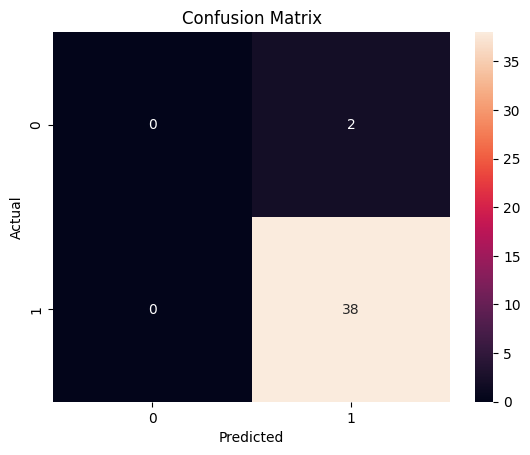

In [16]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Visualize Delay Count

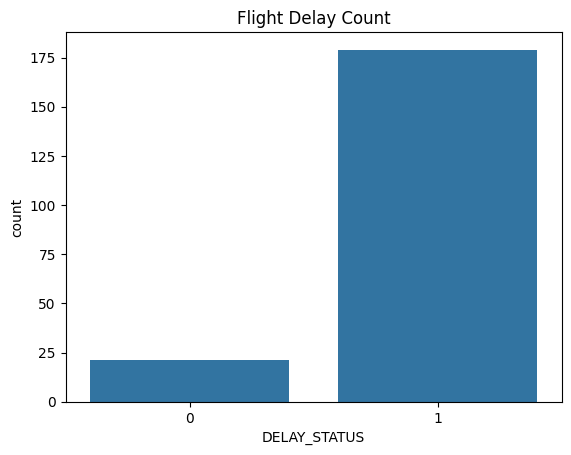

In [17]:
sns.countplot(x='DELAY_STATUS', data=df)

plt.title("Flight Delay Count")

plt.show()

Test with Custom Input

In [18]:
sample = [[1, 2, 3, 1400, 1200]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Flight Will Be Delayed")
else:
    print("Flight Will Be On Time")

Flight Will Be Delayed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Save the Model

In [19]:
import joblib

joblib.dump(model, "flight_delay_model.pkl")

['flight_delay_model.pkl']

Load Saved Model

In [20]:
loaded_model = joblib.load("flight_delay_model.pkl")